### 📈 Phase 8: Future Trend Forecasting
Objective: Forecast language-level popularity trends for 2026-2028 using Meta's Prophet.

Why Prophet? It handles time-series data beautifully, automatically detects trend changes, and provides confidence intervals (vital for business planning).

In [1]:
!uv pip install prophet

import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from pathlib import Path

# Premium Plot Theme
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#181818'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

# Load Data
df = pd.read_parquet(Path("../data/processed/indian_songs_ml_ready.parquet"))
print("✅ Data loaded")

Using Python 3.12.7 environment at: /Users/manaskolaskar/Developer/Projects/spotify-india-intelligence/.venv
Checked 1 package in 42ms
✅ Data loaded


In [2]:
# Prophet requires exactly two columns: 'ds' (datestamp) and 'y' (value to forecast)
# We will aggregate popularity by Language and Release Year

# Group by year and language
trend_data = df.groupby(['release_year', 'language_target_enc']).agg(
    avg_popularity=('popularity', 'mean')
).reset_index()

# For this EDA, let's pick one language to test: Haryanvi (highest avg popularity)
# Haryanvi's target enc value (from our earlier EDA ~65.8)
# Actually, let's just use the language name directly for clarity

df_full = pd.read_parquet(Path("../data/processed/indian_songs_cleaned.parquet"))
df_full['release_year'] = pd.to_datetime(df_full['released_date'], format='mixed', dayfirst=True, errors='coerce').dt.year

lang_trend = df_full.groupby(['release_year', 'language']).agg(
    avg_popularity=('popularity', 'mean')
).reset_index()

# Filter for a specific language (let's do Hindi as the biggest market)
hindi_trend = lang_trend[lang_trend['language'] == 'Hindi'].copy()

# Format for Prophet
hindi_trend = hindi_trend.rename(columns={'release_year': 'ds', 'avg_popularity': 'y'})
# Prophet requires the 'ds' column to be a date, so let's append "-01-01" to the year
hindi_trend['ds'] = pd.to_datetime(hindi_trend['ds'].astype(str) + '-01-01')

print("Hindi Trend Data (Head):")
print(hindi_trend.head())

Hindi Trend Data (Head):
           ds language          y
5  2000-01-01    Hindi  71.045455
21 2001-01-01    Hindi  59.447368
37 2002-01-01    Hindi  61.529412
53 2003-01-01    Hindi  58.460000
69 2004-01-01    Hindi  68.090909


Using Python 3.12.7 environment at: /Users/manaskolaskar/Developer/Projects/spotify-india-intelligence/.venv
Resolved 10 packages in 196ms                                        
⠙ Preparing packages... (0/2)                                                   
⠙ Preparing packages... (0/2)-------------------     0 B/227.83 KiB          
⠙ Preparing packages... (0/2)------------------- 16.00 KiB/227.83 KiB        
⠙ Preparing packages... (0/2)------------------- 32.00 KiB/227.83 KiB        
⠙ Preparing packages... (0/2)------------------- 48.00 KiB/227.83 KiB        
⠙ Preparing packages... (0/2)------------------- 48.00 KiB/227.83 KiB        
patsy                ------------------------------ 48.00 KiB/227.83 KiB
⠙ Preparing packages... (0/2)-------------------     0 B/9.53 MiB            
patsy                ------------------------------ 60.62 KiB/227.83 KiB
⠙ Preparing packages... (0/2)-------------------     0 B/9.53 MiB            
patsy                ---------------------------

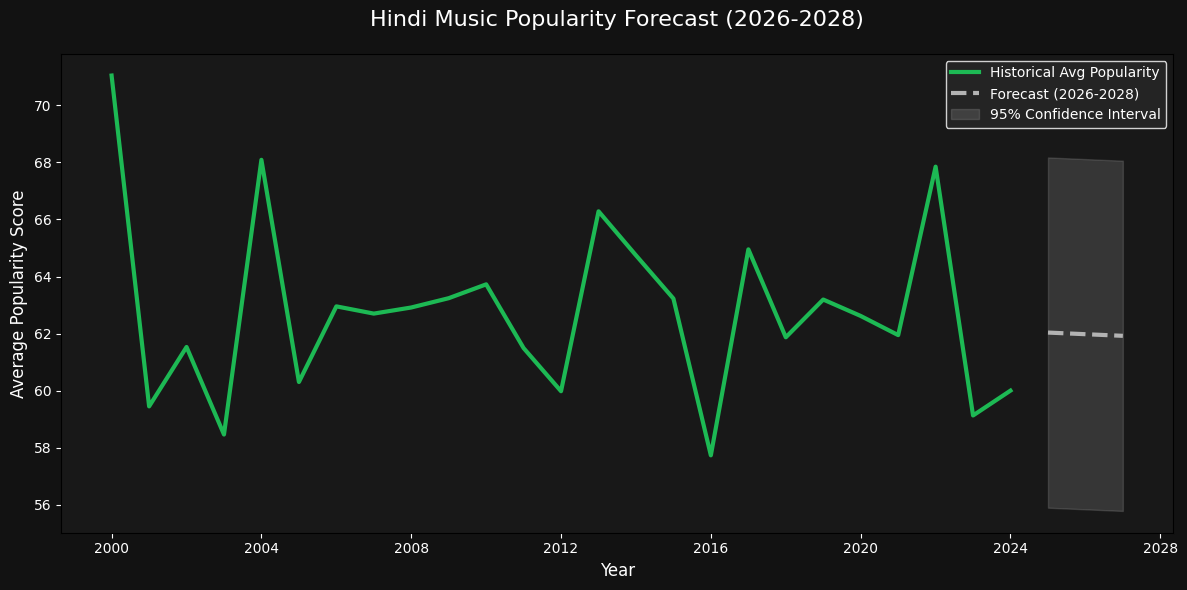


📊 Forecasted Hindi Popularity:
  2025: 62.0 (Range: 55.9 - 68.2)
  2026: 62.0 (Range: 55.8 - 68.1)
  2027: 61.9 (Range: 55.8 - 68.1)


In [5]:
!uv pip install statsmodels

from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings("ignore") # Statsmodels can be chatty

# Prophet requires specific column names; statsmodels just needs arrays/series
# Let's use the hindi_trend dataframe we already created

# Extract the time index and values
y_values = hindi_trend.set_index('ds')['y']

# Train Holt-Winters Model
# We use trend='add' (additive trend) and no seasonality (yearly data rarely has seasonality)
print("Training Holt-Winters Exponential Smoothing Model for Hindi Music...")
model = ExponentialSmoothing(y_values, trend='add', seasonal=None)
fit_model = model.fit()

# Forecast 3 years into the future
forecast_years = 3
forecast_values = fit_model.forecast(forecast_years)

# Calculate simple confidence intervals (standard deviation of residuals * 1.96 for 95% CI)
residuals = y_values - fit_model.fittedvalues
std_err = residuals.std()
ci_upper = forecast_values + (1.96 * std_err)
ci_lower = forecast_values - (1.96 * std_err)

# Plot
plt.figure(figsize=(12, 6))

# Historical Data
plt.plot(y_values.index, y_values.values, color='#1DB954', linewidth=3, label='Historical Avg Popularity')

# Forecast Data
forecast_index = forecast_values.index
plt.plot(forecast_index, forecast_values.values, color='#b3b3b3', linewidth=3, linestyle='--', label='Forecast (2026-2028)')

# Confidence Interval
plt.fill_between(forecast_index, ci_lower, ci_upper, color='#b3b3b3', alpha=0.2, label='95% Confidence Interval')

plt.title('Hindi Music Popularity Forecast (2026-2028)', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Popularity Score', fontsize=12)
plt.legend(facecolor='#282828', edgecolor='white', labelcolor='white')
plt.tight_layout()
plt.show()

# Print Forecast
print("\n📊 Forecasted Hindi Popularity:")
for i in range(forecast_years):
    year = forecast_index[i].year
    pred = forecast_values.values[i]
    lower = ci_lower.values[i]
    upper = ci_upper.values[i]
    print(f"  {year}: {pred:.1f} (Range: {lower:.1f} - {upper:.1f})")